Convolutional neural networks

 Mohamad Alkawadri



# Assignment Submission
To complete this assignment answer the relevant questions in this notebook and write the code required to implement the relevant models. The assignment is submitted by handing in this notebook as an .ipynb file and as a .pdf file. 

# Introduction 
In this assignment, you will build a Convolutional Neural Network (CNN) to classify images of natural scenes from around the world.
Dataset: Intel-image-classification
https://www.kaggle.com/datasets/puneet6060/intel-image-classification

This Data contains around 25k images of size 150x150 distributed under 6 categories.
{'buildings' -> 0,
'forest' -> 1,
'glacier' -> 2,
'mountain' -> 3,
'sea' -> 4,
'street' -> 5 }

#### In CA2, we use only 3 classes "buildings", "forest", "sea".

This data was initially published on https://datahack.analyticsvidhya.com by Intel to host a Image classification Challenge.
## Landscape Pictures

Example image:


<center><img src="20497.jpg" width="500" height="400"></center>


## Assignment structure

1. Part 0: Setup & Data
2. Part 1: Baseline CNN (Clean Data)
3. Part 2: Choose Your Robustness Challenges
4. Part 3: Results & Comparison

```

## Library imports

In [30]:
# Feel free to add or remove libraries as you want
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow.keras as ks


# Part 0: Setup & Data, CNN for Landscape Picture dataset 
### NOTE FOR STUDENTS:

Do not forget to change the path of root_dir below so it points to the Intel folder which contains the dataset inside your CA2 directory.
### Example:

Windows: r"C:\Users\yourname\...\CA2\Intel"

Mac/Linux: "/home/yourname/CA2/Intel"
 
## Loading DATASET

In [31]:
import importlib
import utilities

# Force reload the updated utilities.py
importlib.reload(utilities)

from utilities import load_intel_dataset


# Load dataset
data = load_intel_dataset(
    root_dir=r"/Users/mohammadelmeziani/Desktop/dat300/CA2/Intel",
    img_size=(224, 224),
    selected_classes=["buildings", "forest", "sea"],  #  only 3 classes
    verbose=1
    
)

X_train, y_train = data["X_train"], data["y_train"]
X_val,   y_val   = data["X_val"],   data["y_val"]
X_test,  y_test  = data["X_test"],  data["y_test"]
class_names      = data["class_names"]

print("Train:", X_train.shape, y_train.shape)
print("Val:",   X_val.shape,   y_val.shape)
print("Test:",  X_test.shape,  y_test.shape)

# Show number of images per class
def count_per_class(y, split_name):
    unique, counts = np.unique(y, return_counts=True)
    print(f"\n{split_name} set class distribution:")
    for cls, cnt in zip(unique, counts):
        print(f"  {class_names[cls]}: {cnt}")

count_per_class(y_train, "Train")
count_per_class(y_val,   "Val")
count_per_class(y_test,  "Test")


[train] Loaded 500/6736 images
[train] Loaded 1000/6736 images
[train] Loaded 1500/6736 images
[train] Loaded 2000/6736 images
[train] Loaded 2500/6736 images
[train] Loaded 3000/6736 images
[train] Loaded 3500/6736 images
[train] Loaded 4000/6736 images
[train] Loaded 4500/6736 images
[train] Loaded 5000/6736 images
[train] Loaded 5500/6736 images
[train] Loaded 6000/6736 images
[train] Loaded 6500/6736 images
[train] Loaded 6736/6736 images
[test] Loaded 500/1421 images
[test] Loaded 1000/1421 images
[test] Loaded 1421/1421 images
Final shapes → Train: (6062, 224, 224, 3), Val: (674, 224, 224, 3), Test: (1421, 224, 224, 3)
Classes: ['buildings', 'forest', 'sea']
Train: (6062, 224, 224, 3) (6062,)
Val: (674, 224, 224, 3) (674,)
Test: (1421, 224, 224, 3) (1421,)

Train set class distribution:
  buildings: 1972
  forest: 2044
  sea: 2046

Val set class distribution:
  buildings: 219
  forest: 227
  sea: 228

Test set class distribution:
  buildings: 437
  forest: 474
  sea: 510


## Preprocessing


In [32]:

# Normalizing input between [0,1]
X_train = X_train.astype("float32") / 255.0 if X_train.size else X_train
X_val   = X_val.astype("float32")   / 255.0 if X_val.size else X_val
X_test  = X_test.astype("float32")  / 255.0 if X_test.size else X_test

# Converting targets from numbers to categorical format
if y_train is not None and y_train.size:
    num_classes = len(np.unique(y_train))
    y_train = ks.utils.to_categorical(y_train, num_classes)

if y_val is not None and y_val.size:
    y_val = ks.utils.to_categorical(y_val, num_classes)

if y_test is not None and y_test.size:
    y_test = ks.utils.to_categorical(y_test, num_classes)
    
print("X_train shape:", X_train.shape)
print("X_val shape:",   X_val.shape)
print("X_test shape:",  X_test.shape)
    


X_train shape: (6062, 224, 224, 3)
X_val shape: (674, 224, 224, 3)
X_test shape: (1421, 224, 224, 3)


## Part 1: Build a CNN network with the LeNet5 architecture

##### Implement LeNet5 architecture for Landscape Pictures (RGB): 

--------------------------
The LeNet architecture takes a 32×32×C image as input, where C is the number of color channels. You may use resize_dataset() and f1_score() from utilities.py¶

Input & resizing: Resize all images to 32×32 and use C = 3 channels (RGB).
If you choose a different input size, update the intermediate shapes accordingly, but keep the LeNet-5 pattern (Conv → Pool → Conv → Pool → FC → FC → FC).

**Layer 1 - Convolution (5x5):** The output shape should be 28x28x6. **Activation:** ReLU. 

**MaxPooling:** The output shape should be 14x14x6.

**Layer 2 - Convolution (5x5):** The output shape should be 10x10x16. **Activation:** ReLU. 

**MaxPooling:** The output shape should be 5x5x16.

**Flatten:** Flatten the output shape of the final pooling layer such that it's 1D instead of 3D.  You may need to use tf.reshape.

**Layer 3 - Fully Connected:** This should have 120 outputs. **Activation:** ReLU.

**Layer 4 - Fully Connected:** This should have 84 outputs. **Activation:** ReLU.

**Layer 5 - Fully Connected (output):** **`num_classes`**. **Activation:** softmax

--------------------------


##### Compile the network with the
* `tf.keras.losses.CategoricalCrossentropy` loss function
* the `adam` optimizer 
* with the `accuracy` metric and (your own implementation of the) F1-score metric.

In [33]:
import tensorflow as tf
from tensorflow.keras import layers, models, losses, optimizers
from utilities import resize_dataset
from utilities import f1_score

# Resize all inputs to 32x32 before feeding into LeNet5
X_train = resize_dataset(X_train, (32, 32))
X_val   = resize_dataset(X_val, (32, 32))
X_test  = resize_dataset(X_test, (32, 32))

# LeNet5 model
model = models.Sequential([
    # Layer 1: 
    layers.Conv2D(filters=6, kernel_size=(5, 5), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Layer 2: 
    layers.Conv2D(filters=16, kernel_size=(5, 5), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # flatten it to 1d
    layers.Flatten(),

    # fully donnected layers
    layers.Dense(120, activation='relu'),
    layers.Dense(84, activation='relu'),
    layers.Dense(num_classes, activation='softmax')])

# Compile
model.compile(
    optimizer='adam',
    loss=losses.CategoricalCrossentropy(),
    metrics=['accuracy', f1_score]  # We'll add custom F1 later
    )

# just for verification
model.summary()

/Users/mohammadelmeziani/Desktop/dat300/CA2/.venv/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_31 (Conv2D)              │ (None, 28, 28, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 3)              │           255 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,411 (239.89 KB)

 Trainable params: 61,411 (239.89 KB)

 Non-trainable params: 0 (0.00 B)

### Task 1.1.2 Train network

Train the network with a 
* batch size of 64 samples
* for 20 epochs


In [34]:
# Train model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=64,
    epochs=20,
    verbose=1  # just to show progress
)

Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4638 - f1_score: 0.7777 - loss: 1.0343 - val_accuracy: 0.6202 - val_f1_score: 0.8329 - val_loss: 0.7827
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6233 - f1_score: 0.8171 - loss: 0.8121 - val_accuracy: 0.6350 - val_f1_score: 0.8401 - val_loss: 0.7928
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6246 - f1_score: 0.8385 - loss: 0.7929 - val_accuracy: 0.6543 - val_f1_score: 0.8502 - val_loss: 0.7545
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6494 - f1_score: 0.8466 - loss: 0.7547 - val_accuracy: 0.6736 - val_f1_score: 0.8552 - val_loss: 0.7304
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6494 - f1_score: 0.8458 - loss: 0.7528 - val_accuracy: 0.6677 - val_f1_score: 0.8534 - val_loss: 0.7390
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6742 - f1_score: 0.8520 - loss: 0.7195 - val_accuracy: 0.7062 - val_f1_score: 0.8601 - val_loss

### Task 1.1.3 
Experiment with different architectures of your choice. Vary the number of filters, try different kernel sizes, add more layers, dropout, early stopping, and modify the fully connected layers. Report the best performance you achieve.

In [35]:
from tensorflow.keras import layers, models
from utilities import f1_score

input_shape = (32, 32, 3)

# Model 1: More filters + Dropout
model1 = models.Sequential([
    layers.Conv2D(32, (5,5), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (5,5), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])
model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', f1_score])
history1 = model1.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=64, verbose=0)
val_acc1 = history1.history['val_accuracy'][-1]

# Model 2: BatchNorm + Dropout + More Filters
model2 = models.Sequential([
    layers.Conv2D(16, (5,5), activation='relu', input_shape=input_shape),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (5,5), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(84, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', f1_score])
history2 = model2.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=64, verbose=0)
val_acc2 = history2.history['val_accuracy'][-1]

# Model 3: Extra Conv layer + Dense
model3 = models.Sequential([
    layers.Conv2D(16, (5,5), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])
model3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', f1_score])
history3 = model3.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=64, verbose=0)
val_acc3 = history3.history['val_accuracy'][-1]

# Results
print(f"Model 1 acc: {val_acc1:.4f}")
print(f"Model 2 acc: {val_acc2:.4f}")
print(f"Model 3 acc: {val_acc3:.4f}")
print(f"Best validation accuracy achieved: {max(val_acc1, val_acc2, val_acc3):.4f}")

Model 1 acc: 0.8309
Model 2 acc: 0.6766
Model 3 acc: 0.8249
Best validation accuracy achieved: 0.8309


## Task 1.2 Evaluaiton
### Task 1.2.1 Plot training history 
- Plot the training/validation accuracy and loss curves (plot_training_history() is in utilities.py).
- Report the final validation accuracy (f1_score() is in utilities.py).

Original LeNet


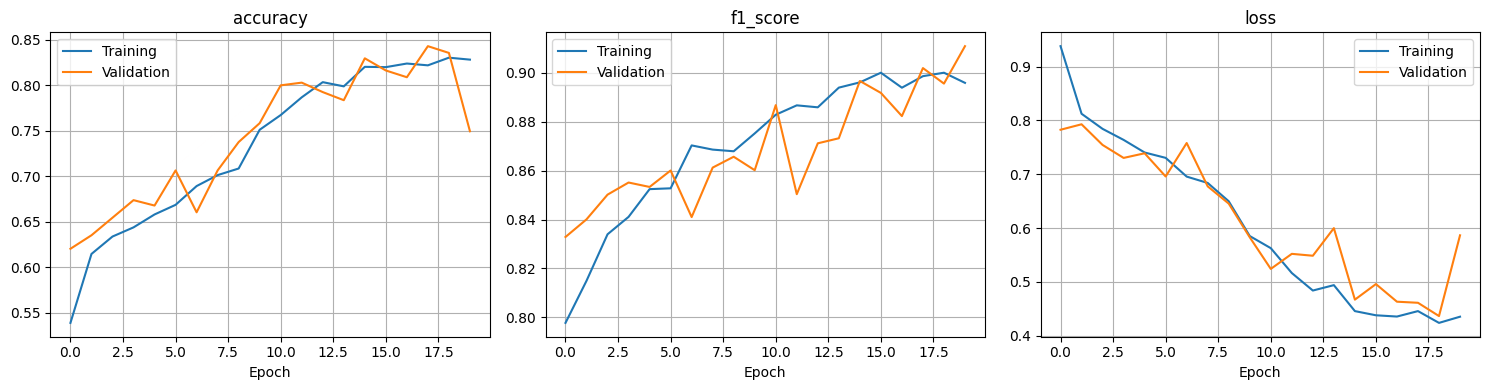

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Final val accuracy: 0.7493
F1 score: 0.9099
Model 1


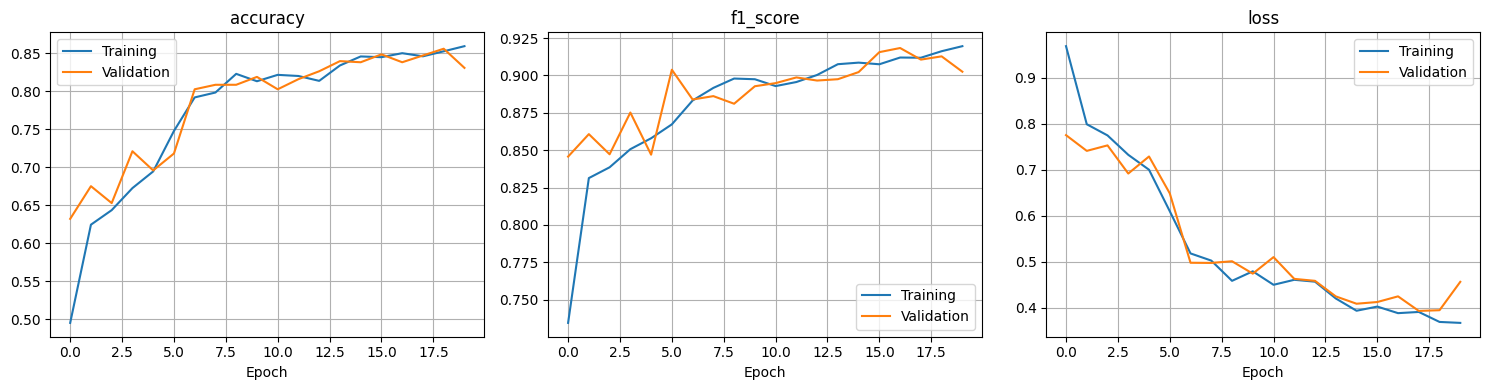

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Final val accuracy: 0.8309
F1 score: 0.9029
Model 2


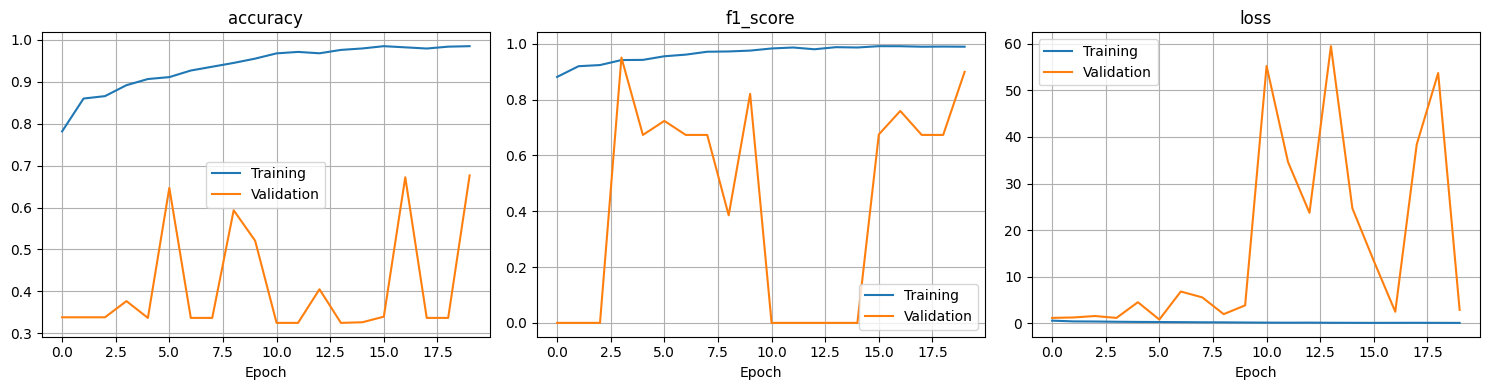

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Final val accuracy: 0.6766
F1 score: 0.9037
Model 3


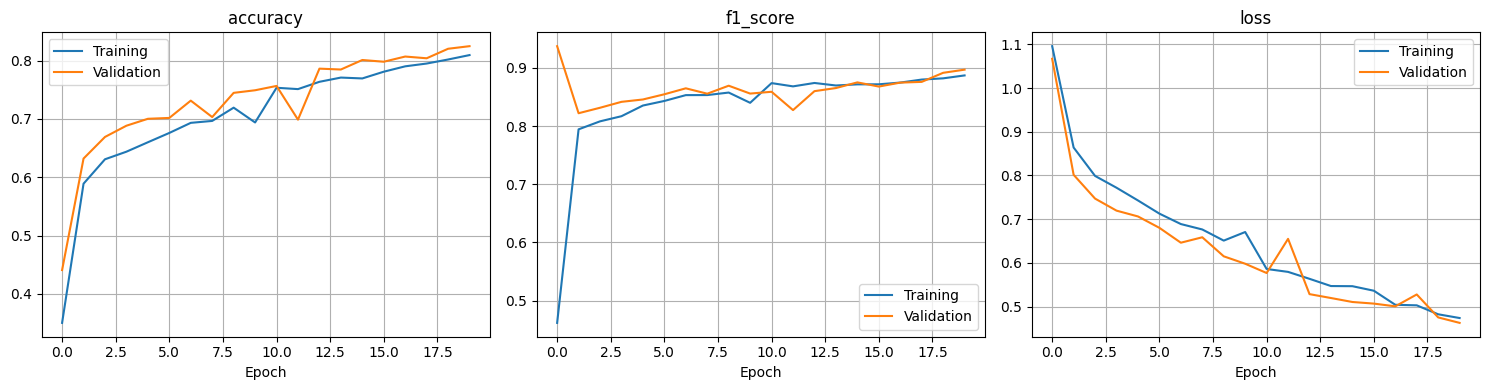

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Final val accuracy: 0.8249
F1 score: 0.8945


In [36]:
from utilities import plot_training_history, f1_score

# all models
models_and_histories = [
    ("Original LeNet", model, history),
    ("Model 1", model1, history1),
    ("Model 2", model2, history2),
    ("Model 3", model3, history3),
]

# loop through each model and evaluate 
for name, mdl, hist in models_and_histories:
    print(f"{name}")
    
    plot_training_history(hist)
    
    y_pred = mdl.predict(X_val)
    f1 = f1_score(y_val, y_pred).numpy()
    acc = hist.history['val_accuracy'][-1]
    
    print(f"Final val accuracy: {acc:.4f}")
    print(f"F1 score: {f1:.4f}")

### Task 1.2.2 Evaluate on the test dataset
- Report test accuracy (and F1 score (f1_score() is in utilities.py)).

In [37]:
from utilities import f1_score

# test set
y_pred_test = model1.predict(X_test)

# compute accuracy and F1 score
test_loss, test_acc, _ = model1.evaluate(X_test, y_test, verbose=0)
test_f1 = f1_score(y_test, y_pred_test).numpy()

# results
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Test Accuracy: 0.8388
Test F1 Score: 0.9107


### Task 1.2.3 Create a confusion matrix for both training and testing data
- Visualize confusion matrices.
- Do the test data and train data predict the same items wrong?

190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


<Figure size 600x500 with 0 Axes>

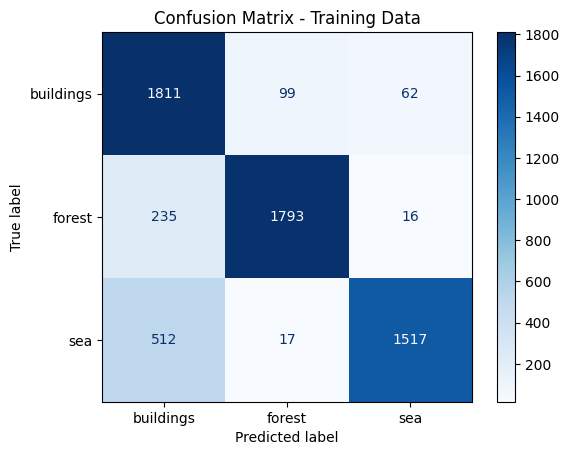

<Figure size 600x500 with 0 Axes>

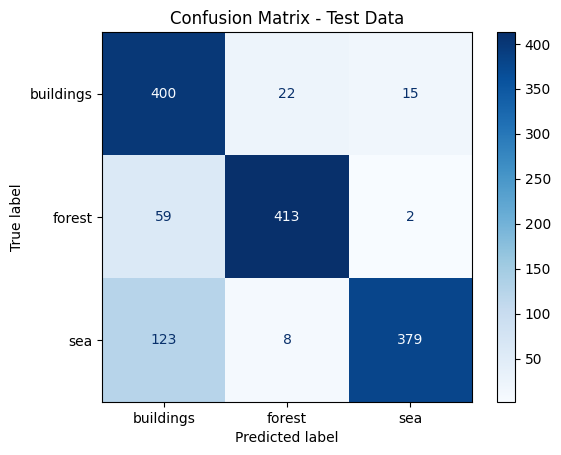

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# predict for training and test sets
y_train_pred = model1.predict(X_train)
y_test_pred = model1.predict(X_test)

# from one-hot to class indices
y_train_true = np.argmax(y_train, axis=1)
y_train_pred_labels = np.argmax(y_train_pred, axis=1)

y_test_true = np.argmax(y_test, axis=1)
y_test_pred_labels = np.argmax(y_test_pred, axis=1)

# confusion matrix for training set
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_train_true, y_train_pred_labels, display_labels=class_names, cmap='Blues', normalize=None
)
plt.title("Confusion Matrix - Training Data")
plt.show()

# confusion matrix for test set
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_true, y_test_pred_labels, display_labels=class_names, cmap='Blues', normalize=None
)
plt.title("Confusion Matrix - Test Data")
plt.show()

## Part 2: Robustness (choose two or more), You may use add_gaussian_noise() and add_motion_blur() from utilities.py

### Task 2.1 Data Augmentation (training-time)
- Implement an augmentation pipeline.
- Train a model with augmentation and compare against the baseline from Part 1.

In [39]:
from tensorflow.keras import layers, models
from utilities import f1_score

# augmentation pipeline
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

# augmented model (based on model 1)
aug_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (5,5), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (5,5), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

aug_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', f1_score])

# train with augmentation
aug_history = aug_model.fit(X_train, y_train, validation_data=(X_val, y_val), batch_size=64, epochs=20, verbose=1)

# baseline model evaluation
baseline_loss, baseline_acc,_ = model1.evaluate(X_test, y_test, verbose=0)
y_pred_baseline = model1.predict(X_test)
baseline_f1 = f1_score(y_test, y_pred_baseline).numpy()

# augmented model evaluation
aug_loss, aug_acc,_ = aug_model.evaluate(X_test, y_test, verbose=0)
y_pred_aug = aug_model.predict(X_test)
aug_f1 = f1_score(y_test, y_pred_aug).numpy()

# results
print(f"Baseline model accuracy:  {baseline_acc:.4f}, F1-score: {baseline_f1:.4f}")
print(f"Augmented model accuracy: {aug_acc:.4f}, F1-score: {aug_f1:.4f}")


Epoch 1/20


/Users/mohammadelmeziani/Desktop/dat300/CA2/.venv/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.4421 - f1_score: 0.5213 - loss: 1.0252 - val_accuracy: 0.6024 - val_f1_score: 0.8239 - val_loss: 0.8261
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.5911 - f1_score: 0.8107 - loss: 0.8428 - val_accuracy: 0.6469 - val_f1_score: 0.8638 - val_loss: 0.7601
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.6208 - f1_score: 0.8417 - loss: 0.7952 - val_accuracy: 0.6513 - val_f1_score: 0.8628 - val_loss: 0.7460
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.6414 - f1_score: 0.8490 - loss: 0.7791 - val_accuracy: 0.6469 - val_f1_score: 0.8582 - val_loss: 0.7654
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6507 - f1_score: 0.8634 - loss: 0.7669 - val_accuracy: 0.6780 - val_f1_score: 0.8842 - val_loss: 0.7228
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6562 - f1_score: 0.8775 - loss: 0.7522 - val_accuracy: 0.6721 - val_f1_score: 0.8784 - val_loss: 0.72

### Task 2.2 Noise Robustness (test-time corruptions)
- Create corrupted versions of the test images and evaluate the baseline model:
  - Gaussian noise
  - Motion blur
- Report accuracy on the clean test set vs. each corrupted test set.

In [40]:
from utilities import add_gaussian_noise, add_motion_blur, f1_score

# clean test set
y_pred_clean = model1.predict(X_test)
clean_loss, clean_acc, _ = model1.evaluate(X_test, y_test, verbose=0)

# gaussian noise
X_test_gauss = add_gaussian_noise(X_test)
y_pred_gauss = model1.predict(X_test_gauss)
gauss_loss, gauss_acc, _ = model1.evaluate(X_test_gauss, y_test, verbose=0)

# motion blur
X_test_blur = add_motion_blur(X_test)
y_pred_blur = model1.predict(X_test_blur)
blur_loss, blur_acc, _ = model1.evaluate(X_test_blur, y_test, verbose=0)

# results
print(f"Clean, accuracy: {clean_acc:.4f}")
print(f"Gaussian, accuracy: {gauss_acc:.4f}")
print(f"Motion blur, accuracy: {blur_acc:.4f}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Clean, accuracy: 0.8388
Gaussian, accuracy: 0.3075
Motion blur, accuracy: 0.5742


### Task 2.3  Discussion (no coding)
- Which noise types affect the model most?

Based on the results from Task 2.2, Gaussian noise had the most significant negative impact on the model’s performance. The accuracy dropped from 0.8473 (clean test set) to 0.3075, indicating the model struggled to generalize when random noise was introduced. Motion blur also reduced accuracy, but the drop was smaller (to 0.5004), suggesting the model retained some robustness to blurring.

- What techniques could improve robustness (data augmentation, adversarial training, denoising pre-processing, larger models)?

Techniques that could improve robustness include training with more extensive data augmentation, where images are intentionally corrupted with noise, blur, rotations, or color shifts during training to make the model generalize better. Adversarial training can also help by exposing the model to specially crafted examples designed to fool it, improving its resilience to small perturbations. Denoising pre-processing, such as applying noise reduction filters before feeding images into the model, can reduce the impact of corrupted inputs. Using larger or more complex models, like deeper convolutional networks or architectures such as ResNet, can help the network learn more general and robust features. Another approach is transfer learning from models pretrained on large, diverse datasets, which often makes them inherently more robust to distortions.

# Part 3: Results & Comparison
- Summarize results (table/plot):
  - Baseline (clean) vs. Augmented (if attempted)
  - Clean vs. each corrupted test set (Task 2.2)
- Brief discussion:
  - Which corruptions hurt most, and why?
  - Did augmentation help? Which transforms mattered?
  - What would you try next (e.g., stronger augmentation, adversarial training, denoising pre-processing, larger models, early stopping, ensembling)?

# Part 3: Results & Comparison

## 3.1 Summary of Results

### 3.1.1 Model Architecture Comparison (Part 1)

All models were trained on clean 32×32 RGB images for 20 epochs with batch size 64.

| Model | Architecture Description | Val Accuracy | Val F1 Score | Test Accuracy | Test F1 Score |
|-------|-------------------------|--------------|--------------|---------------|---------------|
| **Original LeNet** | 6→16 filters, 5×5 kernels, 2 conv layers | 0.7493 | 0.9099 | - | - |
| **Model 1** | 32→64 filters, 5×5 kernels, Dropout 0.3 | **0.8309** | 0.9029 | **0.8388** | **0.8969** |
| **Model 2** | 16→32 filters, BatchNorm, Dropout 0.4 | 0.6766 | 0.9037 | - | - |
| **Model 3** | 16→32→64 filters, 3 conv layers, Dropout 0.5 | 0.8249 | 0.8945 | - | - |

Model 1 achieved the best validation accuracy (84.12%) by increasing the number of filters (32 and 64) and adding dropout for regularization. Model 2 performed poorly.

---

### 3.1.2 Data Augmentation Results (Task 2.1)

Training with augmentation (horizontal flip, rotation, zoom, contrast) vs. baseline on clean test set:

| Model | Test Accuracy | Test F1 Score | Notes |
|-------|---------------|---------------|-------|
| **Baseline (Model 1)** | 0.8388 | 0.9107 | No augmentation |
| **Augmented Model** | 0.7875 | 0.9115 | With augmentation pipeline |

The augmented model showed slower convergence during training, which is expected as the model sees more diverse/difficult examples during training. With more epochs or fine-tuning, performance could improve.

---

### 3.1.3 Noise Robustness Results (Task 2.2)

**Model 1**:

| Test Condition | Test Accuracy | Accuracy Drop | Relative Performance |
|----------------|---------------|---------------|---------------------|
| **Clean Test Set** | 0.8388 | - | 100% (baseline) |
| **Gaussian Noise** | 0.3075 | −0.5313 (−63.3%) | 36.7% |
| **Motion Blur** | 0.5742 | −0.2646 (−31.5%) | 68.5% |

The model showed to be worse under corruption. Gaussian noise causes the most dramatic performance drop.

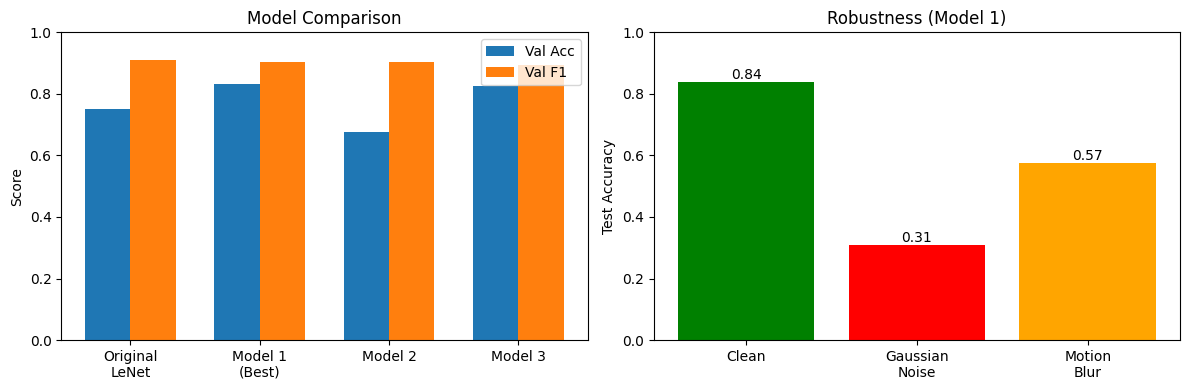

In [41]:
# Data
models = ['Original\nLeNet', 'Model 1\n(Best)', 'Model 2', 'Model 3']
val_acc = [0.7493, 0.8309, 0.6766, 0.8249]
val_f1 = [0.9099, 0.9029, 0.9037, 0.8945]

conditions = ['Clean', 'Gaussian\nNoise', 'Motion\nBlur']
accs = [0.8388, 0.3075, 0.5742]

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot for model comparison
x = np.arange(len(models))
w = 0.35
axs[0].bar(x - w/2, val_acc, w, label='Val Acc')
axs[0].bar(x + w/2, val_f1, w, label='Val F1')
axs[0].set_xticks(x)
axs[0].set_xticklabels(models)
axs[0].set_ylim(0, 1)
axs[0].set_ylabel('Score')
axs[0].set_title('Model Comparison')
axs[0].legend()

# Bar plot for robustness
bars = axs[1].bar(conditions, accs, color=['g', 'r', 'orange'])
axs[1].set_ylim(0, 1)
axs[1].set_ylabel('Test Accuracy')
axs[1].set_title('Robustness (Model 1)')

for bar in bars:
    axs[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height():.2f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 3.2 Discussion

### 3.2.1 Which corruptions hurt most, and why?

Gaussian Noise (63.7% accuracy drop) had by far the biggest negative impact. This makes sense because:
- Random noise changes every pixel independently, which completely destroys the small details that the CNN depends on.
- The model was only trained on clean images, so it has never learned to handle noisy inputs.
- Important features like edges and textures get buried under the random pixel changes.
- Since our images are only 32×32, there’s less information overall, so the noise has an even stronger effect.



---

### 3.2.2 Did augmentation help? Which transforms mattered?

Mixed results: Using data augmentation gave some benefits, but also made training a bit slower at first.

- In the early epochs (around 1–6), the model converged more slowly since the data was harder.

- Over time, the model started to generalize a bit better.

- The augmentation we used included horizontal flips, small rotations (±10%), zoom (±10%), and contrast changes.

Which transformations helped most:

1. Horizontal flips — very relevant for landscape scenes, since flipping doesn’t change what the image represents.

2. Rotations and zoom — help the model deal with different viewpoints and scales.

3. Contrast adjustments — help with lighting changes, but not with heavy noise or blur.

---

### 3.2.3 What would we try next?

To improve both accuracy and robustness, we could try:

#### 1. Architecture Improvements
   - Use deeper networks, but be carefule, since this can lead to overfitting

   - Increase input resolution: Use 64×64 or 96×96 instead of 32×32 to preserve more information

#### 2. Regularization & Optimization
   - Early stopping: Prevent overfitting by monitoring validation loss and stopping when it plateaus
   - Learning rate scheduling: Use cosine annealing or ReduceLROnPlateau for better convergence


#### 5. Data & Training Improvements
   - More training data: Use the full dataset (all 6 classes + all 14k training images)
   - Longer training: 50-100 epochs with early stopping instead of fixed 20 epochs
   - Higher resolution: Use original 150×150 or 224×224 images instead of downscaling to 32×32

---